# Sample Analysis


In [1]:
from pathlib import Path
import os
import re

import numpy as np
import pandas as pd

from HW_HD_utils import *
from plots_utils import *
from create_npy_file import create_npy_file, create_grouped_npy_files, create_npy_file_truncated


def information(data):
    print(f"The shape of the data is: {data.shape}")
    print(f"The type of the data is: {data.dtype}")
    print(f"The first 2 traces are: {data[:2]}")
    print(f"If there are any NaN values: {np.isnan(data).any()}")


In [2]:
sample_registers = ["r0", "r1", "r2", "r3", "r4", "r5", "r6", "r7", "r8", "r9", "r10", "r11", "r12", "sp", "lr"]
sample_trace_dir = "output_decapsulation_sample_TRIM"
result_dir_sample = "Results_decapsulation_sample"

reset_result_dir = False
if reset_result_dir:
    reset_folder(result_dir_sample)
os.makedirs(result_dir_sample, exist_ok=True)

rebuild_npy = False

if rebuild_npy:
    create_grouped_npy_files(result_dir_sample, sample_trace_dir, "HW", sample_registers)
    create_grouped_npy_files(result_dir_sample, sample_trace_dir, "HD", sample_registers)


In [3]:
data_HW_sample = {}
print("Information about data_HW_sample")
print("--------------------------------")
for file in sorted(Path(result_dir_sample).glob("HW_trace_*.npy")):
    idx = int(file.stem.split("_")[-1])
    data_HW_sample[idx] = np.load(file)
    information(data_HW_sample[idx])

data_HD_sample = {}
print("\nInformation about data_HD_sample")
print("--------------------------------")
for file in sorted(Path(result_dir_sample).glob("HD_trace_*.npy")):
    idx = int(file.stem.split("_")[-1])
    data_HD_sample[idx] = np.load(file)
    information(data_HD_sample[idx])


Information about data_HW_sample
--------------------------------
The shape of the data is: (5, 29237)
The type of the data is: float64
The first 2 traces are: [[ 80.  82.  83. ... 146. 136. 137.]
 [ 80.  82.  83. ... 150. 140. 141.]]
If there are any NaN values: False
The shape of the data is: (5, 29237)
The type of the data is: float64
The first 2 traces are: [[ 80.  82.  83. ... 146. 136. 137.]
 [ 80.  82.  83. ... 148. 138. 139.]]
If there are any NaN values: False
The shape of the data is: (5, 29237)
The type of the data is: float64
The first 2 traces are: [[ 80.  82.  83. ... 149. 139. 140.]
 [ 80.  82.  83. ... 151. 141. 142.]]
If there are any NaN values: False
The shape of the data is: (5, 29237)
The type of the data is: float64
The first 2 traces are: [[ 80.  82.  83. ... 146. 136. 137.]
 [ 80.  82.  83. ... 151. 141. 142.]]
If there are any NaN values: False
The shape of the data is: (5, 29237)
The type of the data is: float64
The first 2 traces are: [[ 80.  82.  83. ... 146


Top 3 SNR values for HW 0_1:
1. instruction index = 18743, SNR = 34.1376146788991
2. instruction index = 15091, SNR = 11.029508196721329
3. instruction index = 11439, SNR = 10.428062678062668

Top 3 SNR values for HD 0_1:
1. instruction index = 18742, SNR = 352.80000000000007
2. instruction index = 11438, SNR = 95.35135135135135
3. instruction index = 14867, SNR = 60.49999999999999

Top 3 SNR values for HW 0_2:
1. instruction index = 27415, SNR = 168.01785714285722
2. instruction index = 20111, SNR = 103.26881720430103
3. instruction index = 27871, SNR = 98.01041666666673

Top 3 SNR values for HD 0_2:
1. instruction index = 18742, SNR = 2521.5000000000005
2. instruction index = 5502, SNR = 1944.0000000000002
3. instruction index = 17826, SNR = 1440.0

Top 3 SNR values for HW 0_4:
1. instruction index = 6871, SNR = 174.6691919191919
2. instruction index = 20111, SNR = 174.03080568720375
3. instruction index = 18743, SNR = 163.6904761904762

Top 3 SNR values for HD 0_4:
1. instruction i

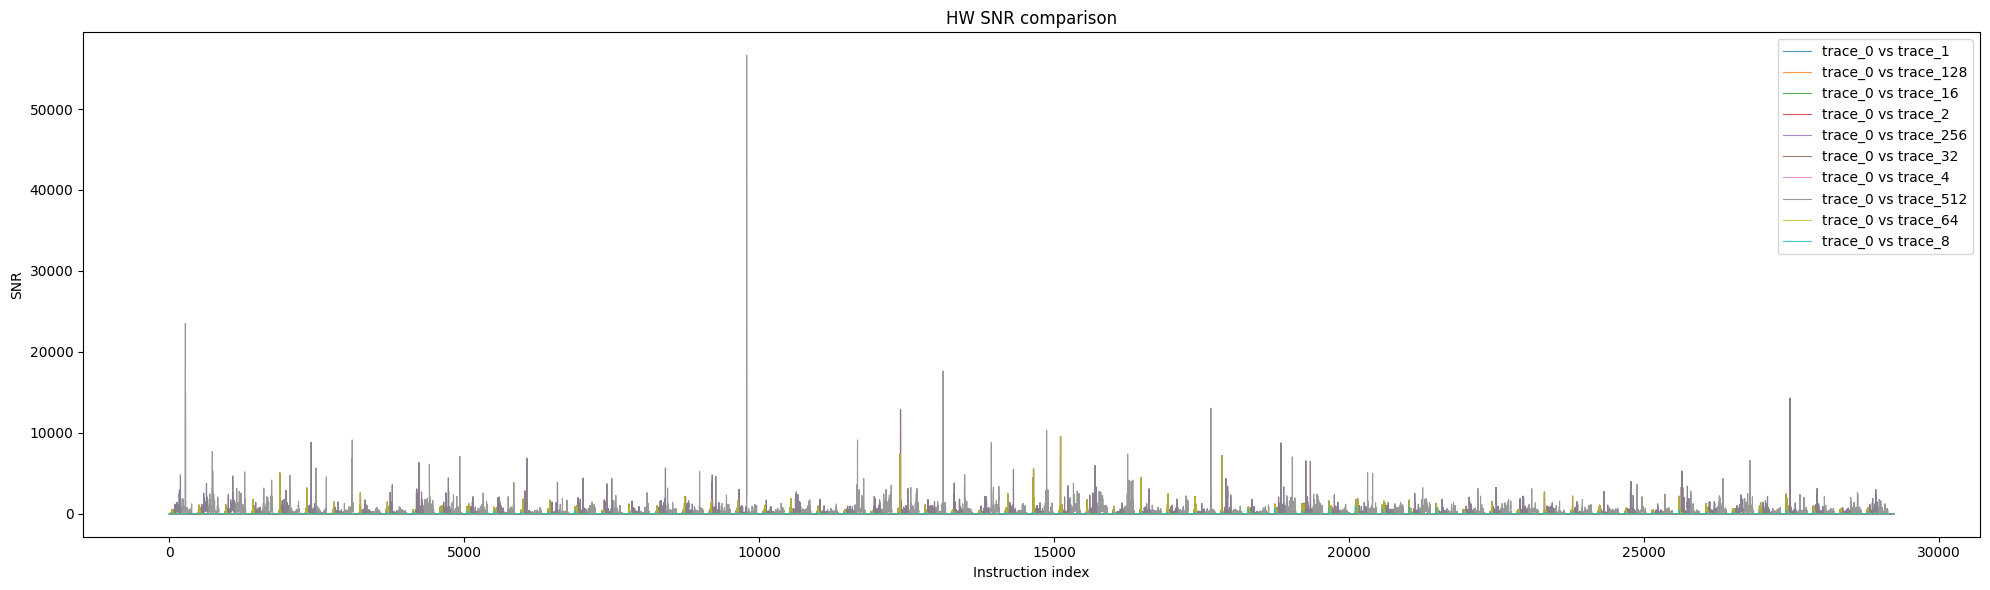

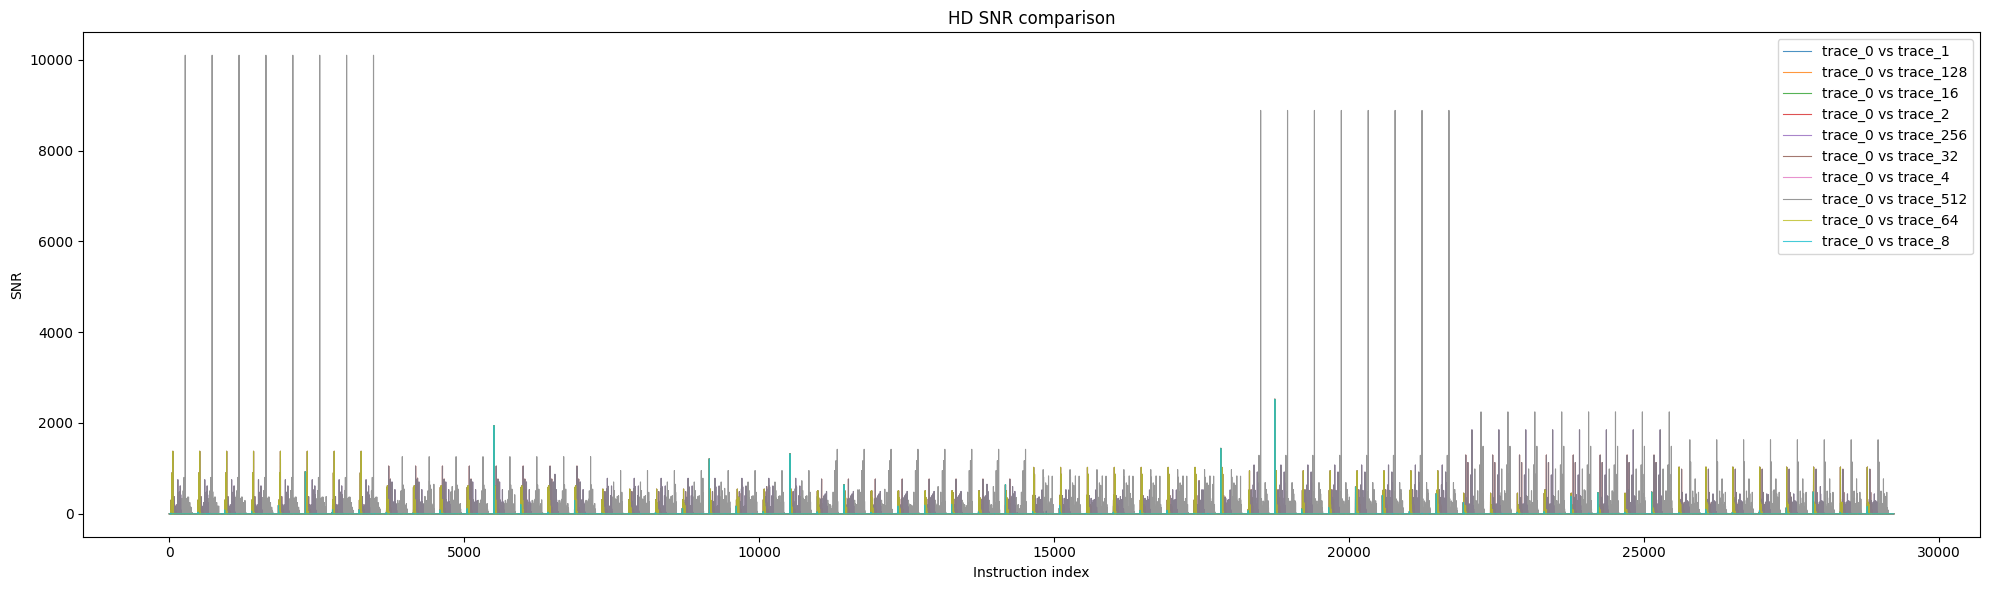

In [4]:
base_index = 0
fault_indices = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

snr_hw = {}
snr_hd = {}

for alt in fault_indices:
    if base_index not in data_HW_sample or alt not in data_HW_sample:
        continue

    key = f"{base_index}_{alt}"
    snr_hw[key] = compute_snr(data_HW_sample[base_index], data_HW_sample[alt])
    snr_hd[key] = compute_snr(data_HD_sample[base_index], data_HD_sample[alt])

    print_top3_snr_indices(snr_hw[key], f"HW {key}")
    print_top3_snr_indices(snr_hd[key], f"HD {key}")

plot_snr_combined({f"trace_{k.replace('_', ' vs trace_')}": v for k, v in snr_hw.items()}, "HW SNR comparison", os.path.join(result_dir_sample, "snr_HW_combined.png"))
plot_snr_combined({f"trace_{k.replace('_', ' vs trace_')}": v for k, v in snr_hd.items()}, "HD SNR comparison", os.path.join(result_dir_sample, "snr_HD_combined.png"))
